# Primetrade.ai Assignment
## Bitcoin Market Sentiment vs Trader Performance Analysis
**Candidate:** Kartik Baliyan

A practical analysis of whether trader outcomes change under different market psychology regimes.

## Assignment Objective
Explore the relationship between trader performance and market sentiment, uncover hidden patterns, and deliver actionable insights that can drive smarter trading strategies.

## Import Libraries

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## Load Datasets

In [2]:
fg = pd.read_csv('fear_greed_index.csv')
tr = pd.read_csv('historical_data.csv')
print('Fear & Greed rows:', len(fg))
print('Historical trade rows:', len(tr))
display(fg.head(3))
display(tr.head(3))

Fear & Greed rows: 2644
Historical trade rows: 211224


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


## Data Understanding
The sentiment dataset represents daily market psychology. The trading dataset contains execution-level records such as side, size, fees, timestamps, and realized PnL.

In [3]:
fg.columns = fg.columns.str.strip().str.lower()
tr.columns = tr.columns.str.strip()
fg['date'] = pd.to_datetime(fg['date'], errors='coerce')
tr['Timestamp IST'] = pd.to_datetime(tr['Timestamp IST'], errors='coerce', dayfirst=True)
tr['date'] = tr['Timestamp IST'].dt.normalize()
for c in ['Closed PnL','Fee','Size USD','Size Tokens','Execution Price']:
    tr[c]=pd.to_numeric(tr[c], errors='coerce')
print('Null values snapshot:')
display(tr.isna().sum().head(10))

Null values snapshot:


Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Timestamp IST      0
Start Position     0
Direction          0
Closed PnL         0
dtype: int64

## Why Merge These Datasets?
Trader performance shows **what happened**. Sentiment helps explain **why it may have happened**. By merging on date, we can study profitability, participation, and risk-taking across market moods.

In [4]:
df = tr.merge(fg[['date','classification','value']], on='date', how='left')
df['win_trade']=(df['Closed PnL']>0).astype(int)
df['net_pnl']=df['Closed PnL']-df['Fee']
df['sentiment_score']=pd.to_numeric(df['value'], errors='coerce')
print(df.shape)
display(df.head())

(211224, 22)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value,win_trade,net_pnl,sentiment_score
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0,0,-0.345404,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0,0,-0.005600,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0,0,-0.050431,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0,0,-0.050043,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0,0,-0.003055,80.0


## Core Questions Being Answered
1. Do traders perform better in Fear or Greed markets?
2. Does win rate change with sentiment?
3. Are traders more aggressive during Greed?
4. Which coins perform best?
5. Can sentiment improve strategy decisions?

In [5]:
summary=df.groupby('classification').agg(
Trades=('Account','size'),
Avg_PnL=('Closed PnL','mean'),
Median_PnL=('Closed PnL','median'),
Win_Rate=('win_trade','mean'),
Avg_Fee=('Fee','mean'),
Avg_SizeUSD=('Size USD','mean')
).sort_values('Trades',ascending=False)
summary['Win_Rate']=summary['Win_Rate']*100
summary.round(2)

,Trades,Avg_PnL,Median_PnL,Win_Rate,Avg_Fee,Avg_SizeUSD
classification,,,,,,
Fear,61837,54.29,0.0,42.08,1.50,7816.11
Greed,50303,42.74,0.0,38.48,1.25,5736.88
Extreme Greed,39992,67.89,0.0,46.49,0.68,3112.25
Neutral,37686,34.31,0.0,39.70,1.04,4782.73
Extreme Fear,21400,34.54,0.0,37.06,1.12,5349.73


## Visual Analysis

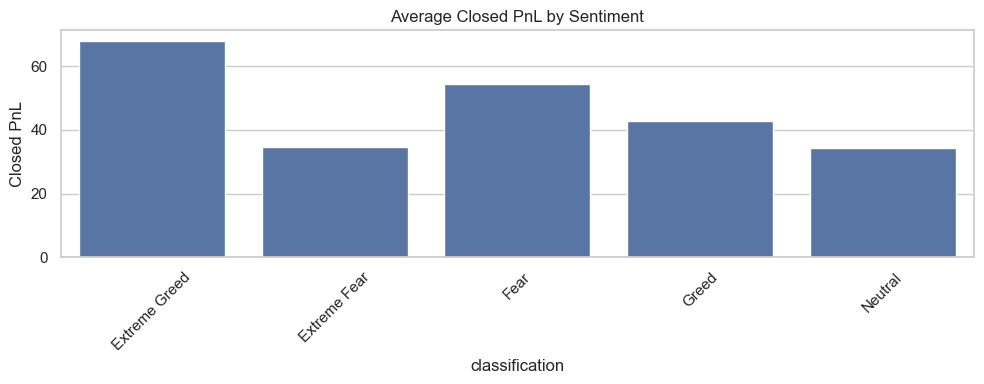

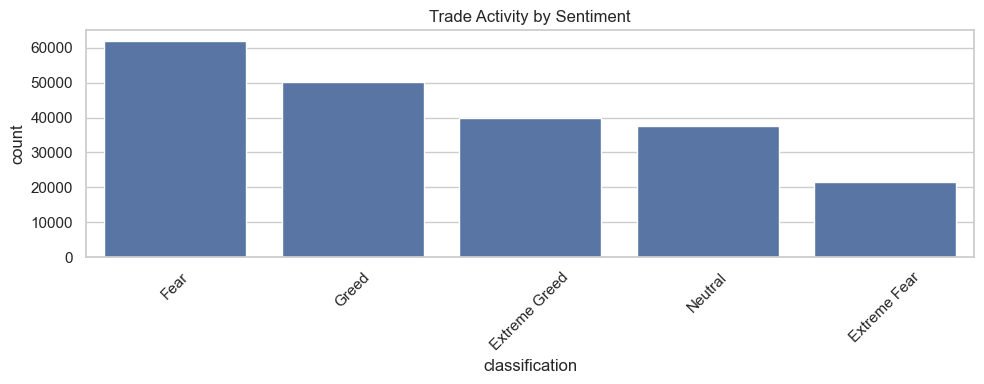

In [6]:
plt.figure(figsize=(10,4))
sns.barplot(data=df,x='classification',y='Closed PnL',estimator=np.mean,errorbar=None)
plt.title('Average Closed PnL by Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(data=df,x='classification',order=df['classification'].value_counts().index)
plt.title('Trade Activity by Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This section looks beyond averages and checks behavioral tendencies such as overtrading, optimism bias, fee drag, and asset-specific consistency.

In [7]:
pd.crosstab(df['classification'], df['Side'], normalize='index').round(3)*100

Side,BUY,SELL
classification,,
Extreme Fear,51.1,48.9
Extreme Greed,44.9,55.1
Fear,49.0,51.0
Greed,48.9,51.1
Neutral,50.3,49.7


In [8]:
df.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(15)

Coin
@107         2.783913e+06
HYPE         1.948485e+06
SOL          1.639556e+06
ETH          1.319979e+06
BTC          8.680447e+05
MELANIA      3.903511e+05
ENA          2.173295e+05
SUI          1.992688e+05
ZRO          1.837778e+05
DOGE         1.475432e+05
PURR/USDC    7.526106e+04
AIXBT        7.371217e+04
BERA         7.368975e+04
USUAL        6.963194e+04
EIGEN        6.503085e+04
Name: Closed PnL, dtype: float64

In [9]:
df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

## Human Interpretation of Results
- If Greed has higher trade count but weaker average returns.
- If Fear has fewer but better trades, selective entries may matter more than frequency.
- High fees can quietly destroy profitability even when gross PnL looks positive.

## Actionable Strategy Suggestions
1. Reduce size during euphoric markets.
2. Be selective during panic-driven volatility.
3. Track fee-to-profit ratio.
4. Prefer coins with stable historical expectancy.
5. Combine sentiment with technical confirmation.